# Genomics of Drug Sensitivity in Cancer (GDSC) — Analysis Notebook

In [ ]:
# Core libraries
import pandas as pd
import numpy as np 

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning / dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures

from sklearn.feature_selection import SelectKBest

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor

# Clustering

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
TARGET_COLUMN = 'LN_IC50'
RANDOM_SEED = 42

## 1. Data Loading

In [3]:
gdsc = pd.read_excel("../data/GDSC.xlsx")

In [4]:
gdsc.head(5)

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [5]:
gdsc.dtypes

COSMIC_ID                                    int64
CELL_LINE_NAME                              object
TCGA_DESC                                   object
DRUG_ID                                      int64
DRUG_NAME                                   object
LN_IC50                                    float64
AUC                                        float64
Z_SCORE                                    float64
GDSC Tissue descriptor 1                    object
GDSC Tissue descriptor 2                    object
Cancer Type (matching TCGA label)           object
Microsatellite instability Status (MSI)     object
Screen Medium                               object
Growth Properties                           object
CNA                                         object
Gene Expression                             object
Methylation                                 object
TARGET                                      object
TARGET_PATHWAY                              object
dtype: object

## MACHINE LEARNING MODELING - PREDICTING LN_IC50

### Preprocessing

Identifiers convey not meaningful biological information, therefore they should be excluded from the dataset. **AUC**, and **Z_SCORE** are alternative measurements of the same information captured by **LN_IC50**. To prevent the introduction of data leakage, they will be exluded as well.

In [6]:
to_excludes = ["COSMIC_ID", "DRUG_ID", "Z_SCORE", "AUC", "Cancer Type (matching TCGA label)"]
df = gdsc.copy()
df.drop(columns=to_excludes, inplace=True)

# Cast all non-numeric columns to 'category'
categorical_columns = df.select_dtypes(exclude='number').columns
for col in categorical_columns:
    df[col] = df[col].astype('category')

print(f"Categorical columns: {list(categorical_columns)}")
print(f"Dataset shape: {df.shape}")

Categorical columns: ['CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']
Dataset shape: (162103, 14)


### SPLIT THE DATASET: TRAINING AND TEST SETS

In [7]:
y = df[TARGET_COLUMN]
X = df.drop(columns=TARGET_COLUMN)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (129682, 13), X_test: (32421, 13)


In [ ]:
# # # sns.heatmap(pd.crosstab(X["GDSC Tissue descriptor 1"], X["GDSC Tissue descriptor 2"]))
# # pd.crosstab(
# #     X["GDSC Tissue descriptor 1"],
# #     X["GDSC Tissue descriptor 2"],
# #     normalize='index'
# # )

# unique_pairs = X[["GDSC Tissue descriptor 1", "GDSC Tissue descriptor 2"]].drop_duplicates()

# unique_pairs.groupby("GDSC Tissue descriptor 1")["GDSC Tissue descriptor 2"].unique()

# # pd.crosstab(
# #     X["TARGET"],
# #     X["TARGET_PATHWAY"],
# #     normalize='index'
# # )

## MODELING

In [29]:
xgb_model = XGBRegressor(
    enable_categorical=True,
    tree_method='hist',        # XGBoost 2.0+
    device='cuda',             # use GPU
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = xgb_model.predict(X_test)

mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2   = r2_score(y_test, predictions)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 0.7325
RMSE: 0.9877
R²  : 0.8794


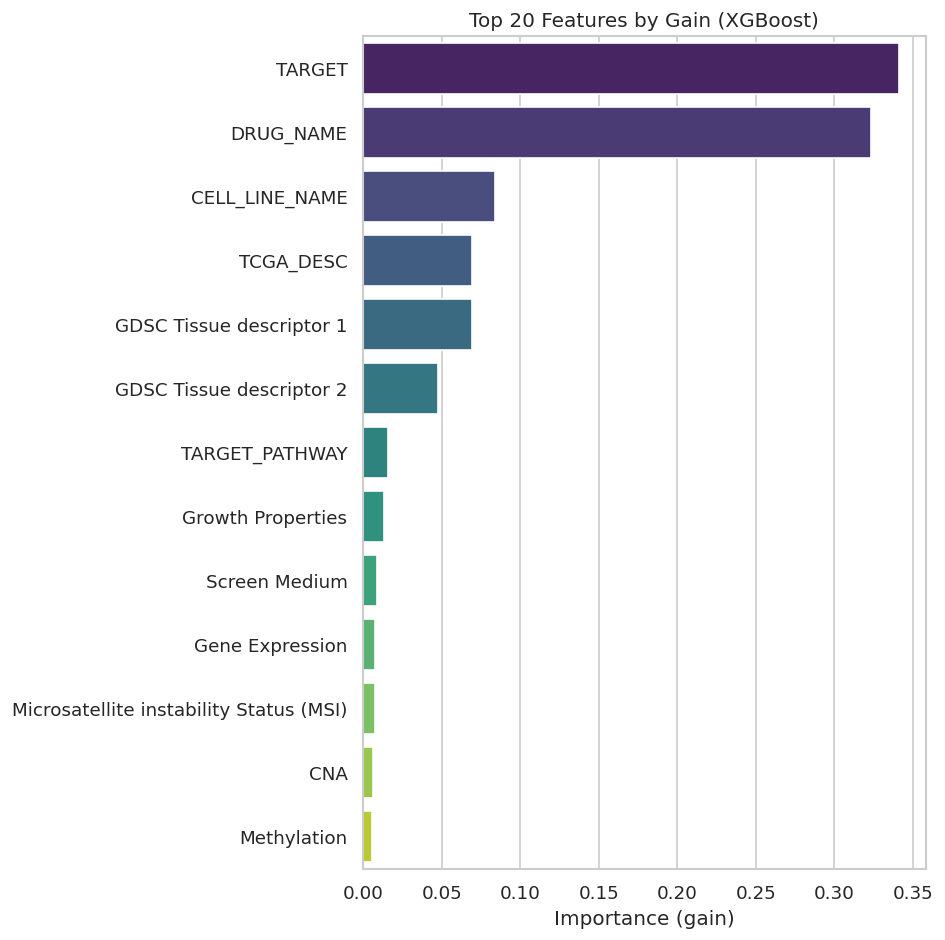

,feature,importance
11,TARGET,0.341241
2,DRUG_NAME,0.323291
0,CELL_LINE_NAME,0.084207
1,TCGA_DESC,0.069410
3,GDSC Tissue descriptor 1,0.069409
4,GDSC Tissue descriptor 2,0.047825
12,TARGET_PATHWAY,0.015661
7,Growth Properties,0.013300
6,Screen Medium,0.008882
9,Gene Expression,0.007516


In [31]:

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_  # uses 'gain' by default
}).sort_values('importance', ascending=False)

# Top 20
plt.figure(figsize=(8, 8))
sns.barplot(
    data=importance_df.head(20),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Top 20 Features by Gain (XGBoost)')
plt.xlabel('Importance (gain)')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(importance_df.head(20))

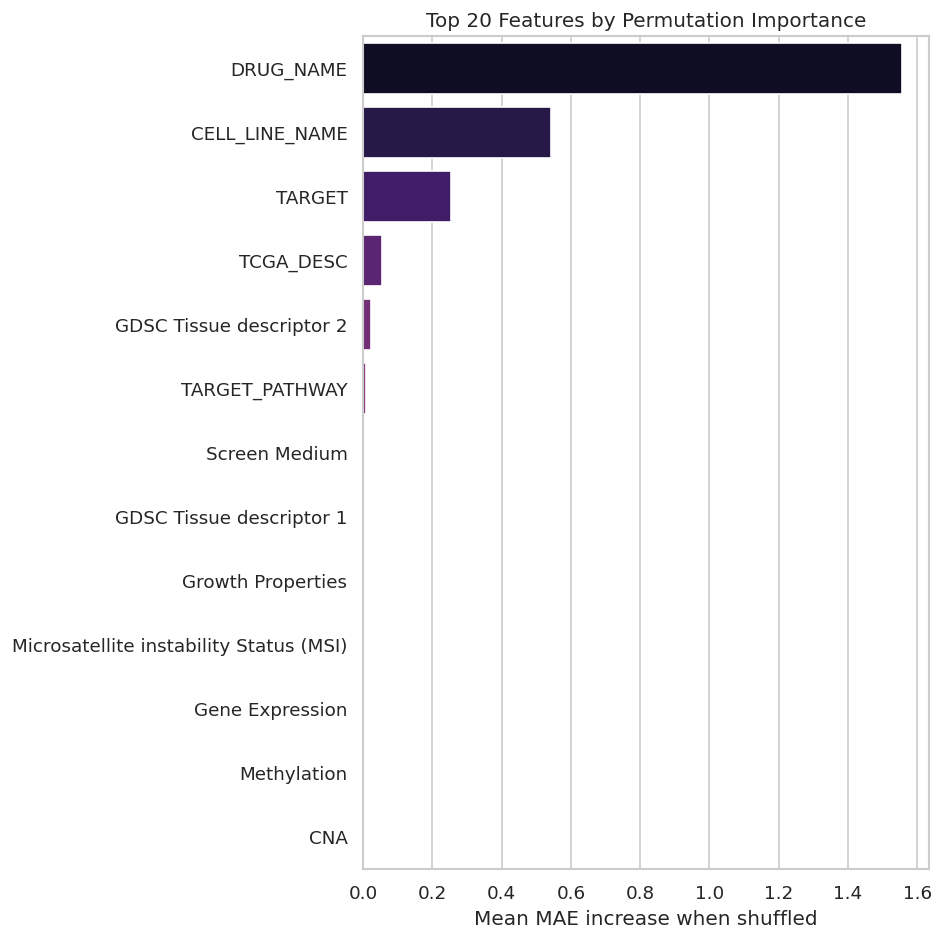

,feature,importance_mean,importance_std
2,DRUG_NAME,1.555669,0.006026
0,CELL_LINE_NAME,0.542154,0.001999
11,TARGET,0.253367,0.002452
1,TCGA_DESC,0.054139,0.000786
4,GDSC Tissue descriptor 2,0.021913,0.000310
12,TARGET_PATHWAY,0.006671,0.000218
6,Screen Medium,0.003223,0.000181
3,GDSC Tissue descriptor 1,0.002754,0.000156
7,Growth Properties,0.002041,0.000174
5,Microsatellite instability Status (MSI),0.000393,0.000093


In [32]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    xgb_model,
    X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(
    data=perm_df.head(20),
    x='importance_mean',
    y='feature',
    palette='magma'
)
plt.title('Top 20 Features by Permutation Importance')
plt.xlabel('Mean MAE increase when shuffled')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(perm_df.head(20))